In [1]:
import numpy as np
import sys
from diversity.diversty import Diversity

In [2]:
from option1.env import Environment

# Define environment, inputs and outputs

## Parameters for simulation

In [3]:
simu_params = {
"min_address" : 0,
"max_address" : 19,
"max_instructions" : 10,
}
max_cycle = 60 #Maximum cycle in simulation
step = 3

In [4]:
environment = Environment(step = step,max_instructions=10)

## Inputs

In [5]:
from option1.codegeneration import Address_Management 

In [6]:
addr_management = Address_Management(**simu_params)
address_x=5
code_generation_method = lambda: addr_management.generate_instruction_sequence(address_x = address_x)

## Ouputs

In [7]:
instructions = code_generation_method()
environment(instructions)

{'cache_hit_l1': {0: 0, 1: 2, 2: 0, 3: 0},
 'cache_hit_l2': {0: 1, 1: 0, 2: 0, 3: 0},
 'cache_misses_l1': {0: 3, 1: 1, 2: 0, 3: 0},
 'cache_misses_l2': {0: 1, 1: 0, 2: 0, 3: 0},
 'time_core0': 62}

# IMGEP parameters

In [8]:
from option1.history import History
from option1.OptimizationPolicy import OptimizationPolicykNN
from option1.distance import DistanceMethod
from option1.mutation import MutationInstructions
from option1.mix_interleaving import Mix_sequences_interleaved
from option1.goal_generation import GoalGenerator
from option1.imgep import run_imgep,Randomexploration

In [9]:
k = 1 #Number of neighbors in goal achievement strategy
N = 1000 #Number of imgep iterations
capacity = N #History capacity
N_init = 100 #Number of warming iterations
num_mutations = 3 #Nb of mutations in goal achievement strategy
#address X to work on
address_x = 5
print_freq = 100 #print iteration step every print_freq

## Distance function

In [10]:
def distance_function(goal,features):
    x = goal
    v = x-features
    out = np.sum(v**2,axis=1)
    return out

In [11]:
history = History(capacity=capacity,unused=['time_core0'])

#goal generation
goalgenerator = GoalGenerator(history)

#optimization policy models

mutation_method = MutationInstructions(num_mutations,**simu_params)
mixing_method   = Mix_sequences_interleaved(max_cycle)

distance_method = DistanceMethod(distance_function)

### Run imgep

In [12]:
run_imgep(N_init=N_init,
        N=N,
        capacity=capacity,
        k=k,
        environment = environment,
        history=history,
        code_generation_method = code_generation_method,
        goal_generator=goalgenerator,
        distance_method=distance_method,
        mutation_method=mutation_method,
        mixing_method=mixing_method,
        )

initilization
run random exploration


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 825.59it/s]


start of imgep


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 900/900 [00:01<00:00, 722.12it/s]

1.3746004104614258


### Run random exploration for comparison

In [13]:
history_rand = History(capacity=capacity,unused=['time_core0'])
random_explorer = Randomexploration(N,environment,code_generation_method,history_rand)
random_explorer()

run random exploration


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:01<00:00, 858.13it/s]


### Evaluation

In [14]:
dim_out = history_rand.numpy_view.shape[1]
diversity_ = Diversity(min_tab = np.zeros((dim_out,)),
                        max_tab = np.ones((dim_out,))*10,
                        num_bins = 10)
diversity_imgep_list = [diversity_(history.as_tab()[:print_freq*step]) for step in range(N//print_freq)]
diversity_random_list = [diversity_(history_rand.as_tab()[:print_freq*step]) for step in range(N//print_freq)]

In [15]:
import matplotlib.pyplot as plt

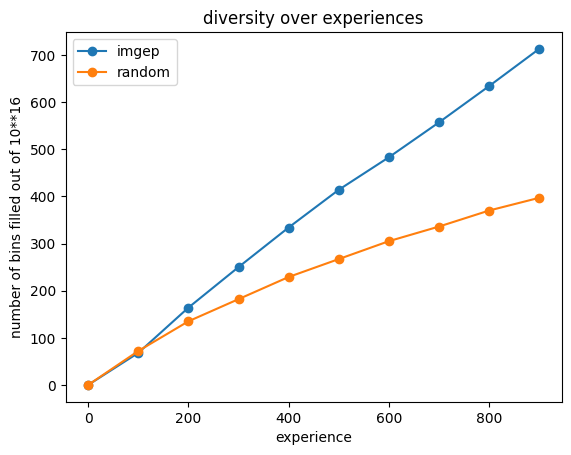

In [16]:
plt.plot(range(0,N,print_freq),diversity_imgep_list,'-o',label="imgep")
plt.plot(range(0,N,print_freq),diversity_random_list,'-o',label="random")
plt.legend()
plt.title('diversity over experiences')
plt.xlabel('experience')
plt.ylabel(f'number of bins filled out of 10**{dim_out}')
plt.show()

In [17]:
history_rand.memory_observation.keys()

dict_keys(['cache_hit_l1', 'cache_hit_l2', 'cache_misses_l1', 'cache_misses_l2', 'time_core0'])